# Bilan de la recherche GPT — challenge QRT

Ce notebook remet les expériences à plat. Il distingue les résultats robustes,
les signaux intéressants mais fragiles, et les problèmes de validation révélés
par le score public.

**Contraintes respectées :** dates gardées entières dans les folds, aucun ordre
des dates anonymisées, aucun target encoding et aucune reconstruction des
fenêtres.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data import ChallengeDataLoader

OUT = ROOT / "gpt" / "outputs"
sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"reference": "#2563A6", "candidate": "#D97706", "rejected": "#8A94A6", "alert": "#C44536"}
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})

def label_bars(ax, digits=3):
    for patch in ax.patches:
        value = patch.get_width() if patch.get_width() > patch.get_height() else patch.get_height()
        if np.isfinite(value):
            ax.annotate(f"{value:.{digits}f}", (patch.get_x() + patch.get_width()/2, patch.get_y() + patch.get_height()),
                        ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

print(f"Racine : {ROOT}")

Racine : /Users/macbookpro/Desktop/Machine_Learning/challenge_data_ens/data_challenge_qrt


## 1. Résultat honnête à retenir

La logistique V2 reste la référence CV globale. Plusieurs candidats gagnent
quelques centièmes de point, mais leurs gains ne sont pas stables. Le score
public proche de 50 % montre surtout que la CV globale n'est pas suffisamment
représentative du régime test.

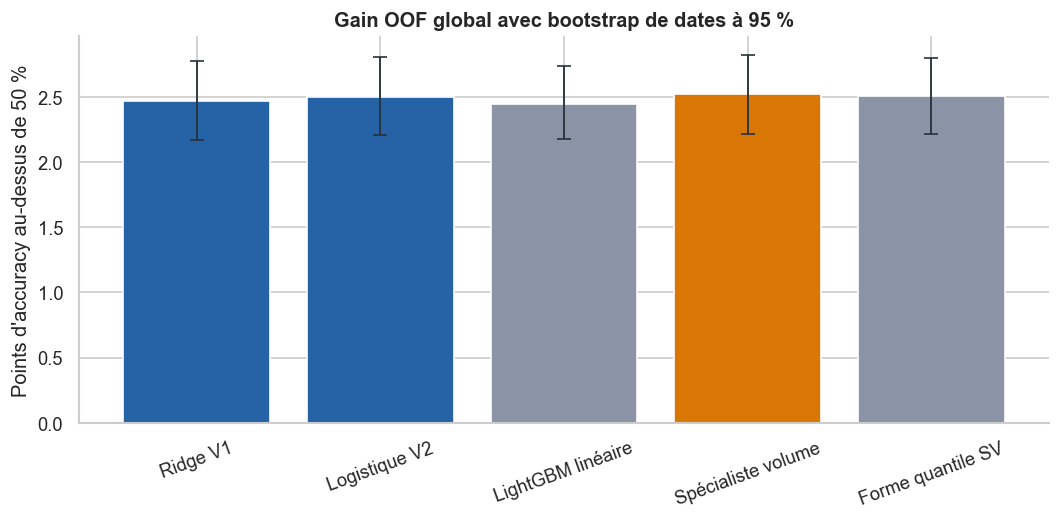

,model,accuracy,accuracy_ci_low,accuracy_ci_high,gain_vs_v2,gain_ci_low,gain_ci_high
0,Ridge V1,0.524709,0.521692,0.527737,-0.000292,-0.001451,0.000843
1,Logistique V2,0.525001,0.522050,0.528027,0.000000,0.000000,0.000000
2,LightGBM linéaire,0.524442,0.521775,0.527390,-0.000560,-0.002232,0.001049
3,Spécialiste volume,0.525185,0.522172,0.528231,0.000184,-0.000951,0.001368
4,Forme quantile SV,0.525024,0.522148,0.527989,0.000023,-0.000769,0.000829


In [2]:
uncertainty = pd.read_csv(OUT / "hypotheses_h1_h2_h3" / "model_uncertainty.csv")
models = uncertainty[uncertainty.scope.eq("Toutes dates")].copy()
models["gain_vs_50_pp"] = 100 * (models.accuracy - .5)
models["low_vs_50_pp"] = 100 * (models.accuracy_ci_low - .5)
models["high_vs_50_pp"] = 100 * (models.accuracy_ci_high - .5)

fig, ax = plt.subplots(figsize=(9, 4.5))
palette = [COLORS["reference"], COLORS["reference"], COLORS["rejected"], COLORS["candidate"], COLORS["rejected"]]
ax.bar(np.arange(len(models)), models.gain_vs_50_pp, color=palette)
ax.errorbar(np.arange(len(models)), models.gain_vs_50_pp,
            yerr=np.vstack([models.gain_vs_50_pp-models.low_vs_50_pp,
                            models.high_vs_50_pp-models.gain_vs_50_pp]),
            fmt="none", ecolor="#263238", elinewidth=1.1, capsize=4)
ax.set_xticks(np.arange(len(models)), models.model)
ax.set(title="Gain OOF global avec bootstrap de dates à 95 %",
       ylabel="Points d'accuracy au-dessus de 50 %", xlabel="")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
models[["model", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
        "gain_vs_v2", "gain_ci_low", "gain_ci_high"]]

## 2. Le régime dominant du test change le classement

Le test contient surtout des dates de 278 lignes. Le train contient un régime
proche à 276 lignes, mais aussi beaucoup de dates plus petites. Sur ce régime
complet, tous les scores baissent fortement.

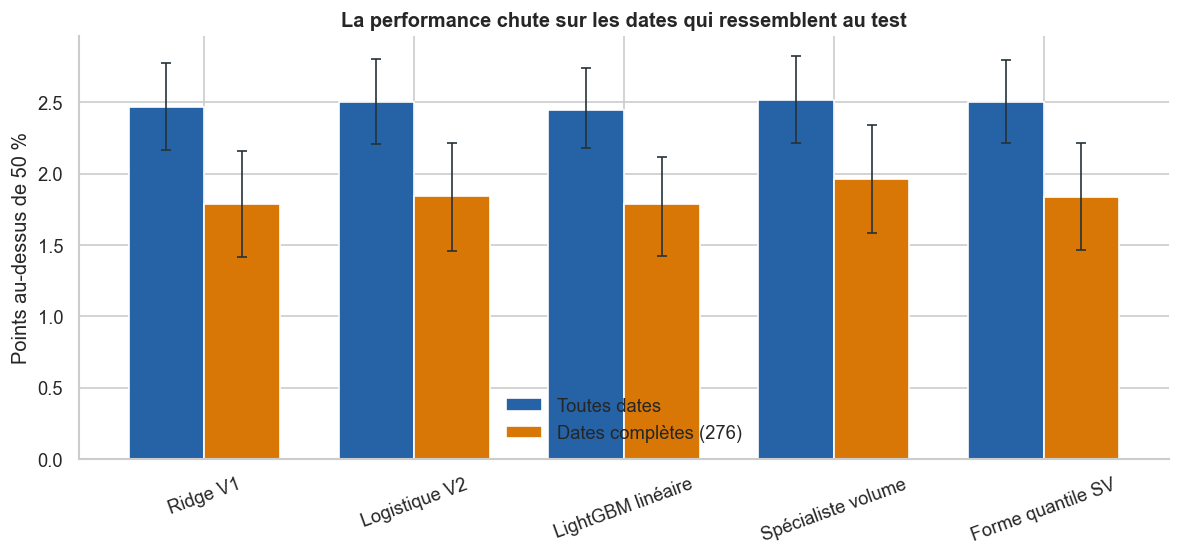

,model,scope,accuracy,accuracy_ci_low,accuracy_ci_high,gain_vs_v2,gain_ci_low,gain_ci_high
0,Ridge V1,Toutes dates,0.524709,0.521692,0.527737,-0.000292,-0.001451,0.000843
1,Logistique V2,Toutes dates,0.525001,0.522050,0.528027,0.000000,0.000000,0.000000
2,LightGBM linéaire,Toutes dates,0.524442,0.521775,0.527390,-0.000560,-0.002232,0.001049
3,Spécialiste volume,Toutes dates,0.525185,0.522172,0.528231,0.000184,-0.000951,0.001368
4,Forme quantile SV,Toutes dates,0.525024,0.522148,0.527989,0.000023,-0.000769,0.000829
5,Ridge V1,Dates complètes (276),0.517877,0.514160,0.521620,-0.000561,-0.002084,0.000843
6,Logistique V2,Dates complètes (276),0.518438,0.514595,0.522155,0.000000,0.000000,0.000000
7,LightGBM linéaire,Dates complètes (276),0.517843,0.514196,0.521201,-0.000595,-0.002613,0.001435
8,Spécialiste volume,Dates complètes (276),0.519650,0.515827,0.523444,0.001212,-0.000265,0.002616
9,Forme quantile SV,Dates complètes (276),0.518364,0.514671,0.522118,-0.000074,-0.001056,0.000914


In [3]:
X_train = ChallengeDataLoader.load_X_train()
X_test = ChallengeDataLoader.load_X_test()
train_sizes = X_train.groupby("TS").size()
test_sizes = X_test.groupby("TS").size()
complete_dates = train_sizes[train_sizes.eq(276)].index

oof_files = {
    "Ridge V1": OUT / "v1_recheck" / "oof_predictions.csv",
    "Logistique V2": OUT / "classification_full" / "oof_logistic_C_0.003.csv",
    "LightGBM linéaire": OUT / "v3_lgbm_linear_full8" / "oof_lgbm_linear_returns_compact_full.csv",
    "Spécialiste volume": OUT / "volume_specialist_full8" / "oof_observed_returns_C_0.003.csv",
    "Forme quantile SV": OUT / "quantile_shape_full8" / "oof_sv_positive_shape_C_0.003.csv",
}
regime = uncertainty.copy()
regime["gain_vs_50_pp"] = 100 * (regime.accuracy - .5)
regime["low_vs_50_pp"] = 100 * (regime.accuracy_ci_low - .5)
regime["high_vs_50_pp"] = 100 * (regime.accuracy_ci_high - .5)

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(regime.model.nunique()); width = .36
model_order = regime[regime.scope.eq("Toutes dates")].model.tolist()
for offset, scope, color in [(-width/2, "Toutes dates", "#2563A6"),
                             (width/2, "Dates complètes (276)", "#D97706")]:
    d = regime[regime.scope.eq(scope)].set_index("model").loc[model_order]
    ax.bar(x+offset, d.gain_vs_50_pp, width, color=color, label=scope)
    ax.errorbar(x+offset, d.gain_vs_50_pp,
                yerr=np.vstack([d.gain_vs_50_pp-d.low_vs_50_pp,
                                d.high_vs_50_pp-d.gain_vs_50_pp]),
                fmt="none", ecolor="#263238", elinewidth=1, capsize=3)
ax.set(title="La performance chute sur les dates qui ressemblent au test", ylabel="Points au-dessus de 50 %", xlabel="")
ax.set_xticks(x, model_order)
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
regime[["model", "scope", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
        "gain_vs_v2", "gain_ci_low", "gain_ci_high"]]

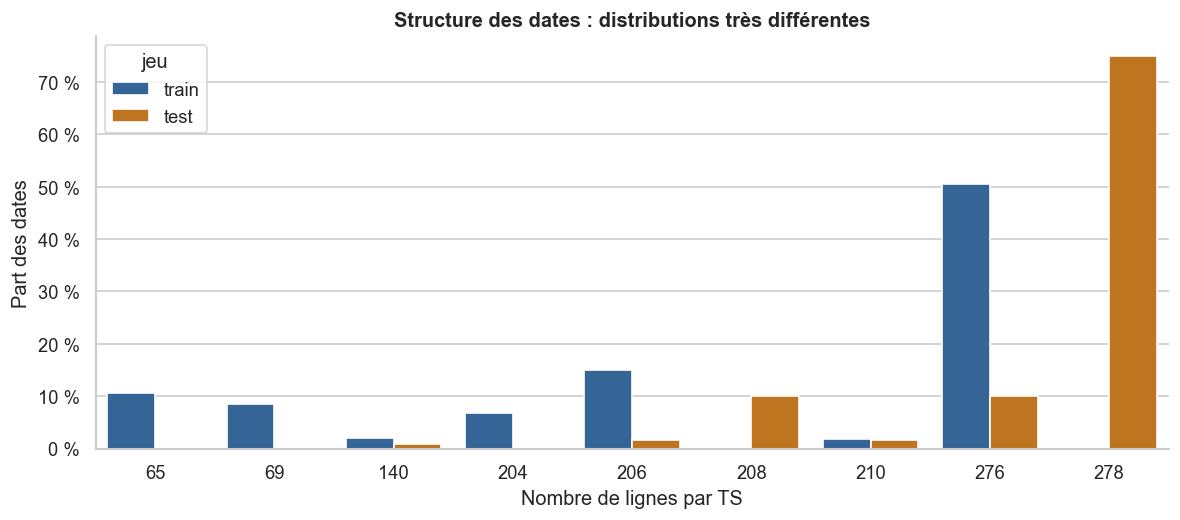

,train,test
count,2522.000000,120.000000
mean,208.990087,265.583333
std,81.903327,32.054466
min,65.000000,70.000000
25%,140.000000,277.500000
50%,276.000000,278.000000
75%,276.000000,278.000000
max,276.000000,278.000000


In [4]:
sizes = pd.concat([
    train_sizes.value_counts(normalize=True).rename("part").reset_index().assign(jeu="train"),
    test_sizes.value_counts(normalize=True).rename("part").reset_index().assign(jeu="test"),
])
sizes.columns = ["lignes_par_date", "part", "jeu"]
sizes = sizes[sizes.lignes_par_date.isin(sorted(set(sizes.nlargest(10, "part").lignes_par_date)))]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=sizes, x="lignes_par_date", y="part", hue="jeu", palette=["#2563A6", "#D97706"], ax=ax)
ax.set(title="Structure des dates : distributions très différentes", xlabel="Nombre de lignes par TS", ylabel="Part des dates")
ax.yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f} %")
plt.tight_layout(); plt.show()
pd.DataFrame({"train": train_sizes.describe(), "test": test_sizes.describe()})

## 3. Calibration : pourquoi 60 % de positifs ?

La cible train contient 50,72 % de positifs, mais V2 en prédit environ 60 % en
OOF comme en test. Les distributions de probabilités OOF et test sont pourtant
presque identiques : le problème est déjà présent dans la CV et vient de scores
très concentrés autour de 0,5.

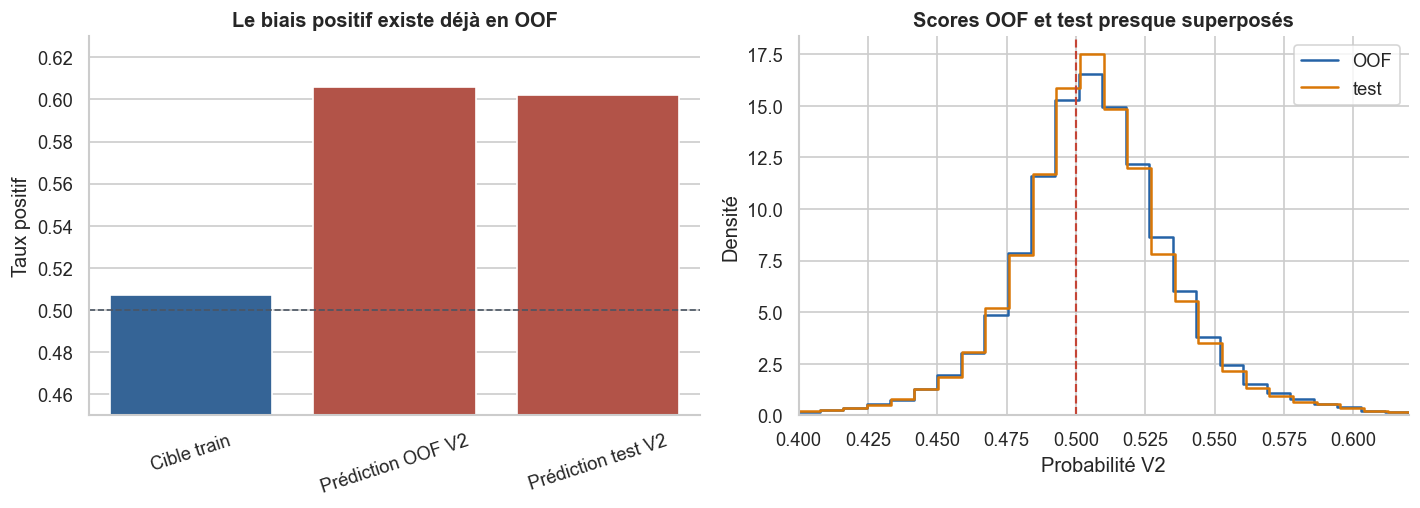

,mesure,taux positif
0,Cible train,0.507184
1,Prédiction OOF V2,0.606030
2,Prédiction test V2,0.602259


In [5]:
oof_v2 = pd.read_csv(OUT / "classification_full" / "oof_logistic_C_0.003.csv")
test_v2 = pd.read_csv(OUT / "v2" / "test_predictions.csv")
y_train = ChallengeDataLoader.load_y_train()
rates = pd.DataFrame({
    "mesure": ["Cible train", "Prédiction OOF V2", "Prédiction test V2"],
    "taux positif": [y_train.target_binarized.mean(), oof_v2.prediction.mean(), test_v2.prediction.mean()],
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=rates, x="mesure", y="taux positif", hue="mesure", legend=False,
            palette=[COLORS["reference"], COLORS["alert"], COLORS["alert"]], ax=axes[0])
axes[0].axhline(.5, color="#4B5563", ls="--", lw=1)
axes[0].set(title="Le biais positif existe déjà en OOF", xlabel="", ylabel="Taux positif", ylim=(.45, .63))
axes[0].tick_params(axis="x", rotation=18)

sns.histplot(oof_v2.score.sample(60000, random_state=0), bins=70, stat="density", element="step", fill=False,
             color="#2563A6", label="OOF", ax=axes[1])
sns.histplot(test_v2.probability_positive, bins=70, stat="density", element="step", fill=False,
             color="#D97706", label="test", ax=axes[1])
axes[1].axvline(.5, color="#C44536", ls="--", lw=1.3)
axes[1].set(title="Scores OOF et test presque superposés", xlabel="Probabilité V2", ylabel="Densité", xlim=(.40, .62))
axes[1].legend()
plt.tight_layout(); plt.show()
rates

## 4. Les erreurs des modèles sont fortement corrélées

Le spécialiste volume et les transformations quantiles corrigent peu de lignes
différentes. LightGBM est plus divers, mais moins précis. Un stacking naïf ne
peut donc pas résoudre une chute de plusieurs points sur le public.

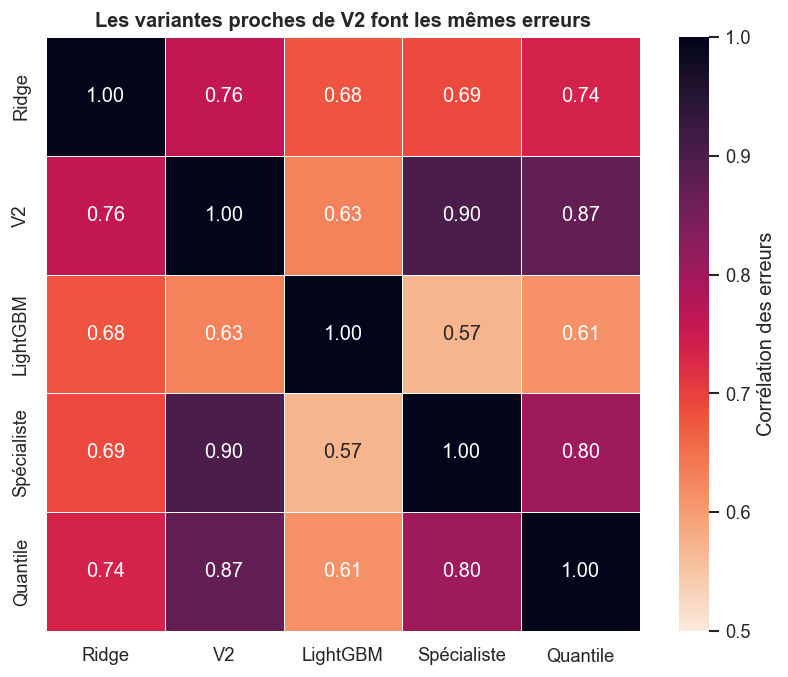

,Ridge,V2,LightGBM,Spécialiste,Quantile
Ridge,1.000000,0.760611,0.679182,0.689399,0.735337
V2,0.760611,1.000000,0.630583,0.902192,0.871621
LightGBM,0.679182,0.630583,1.000000,0.570760,0.614895
Spécialiste,0.689399,0.902192,0.570760,1.000000,0.801793
Quantile,0.735337,0.871621,0.614895,0.801793,1.000000


In [6]:
corr = pd.read_csv(OUT / "error_correlation_audit" / "error_correlation.csv", index_col=0)
labels = {"ridge_v1":"Ridge", "logistic_v2":"V2", "lgbm_linear":"LightGBM",
          "volume_specialist":"Spécialiste", "sv_quantile_shape":"Quantile"}
corr = corr.rename(index=labels, columns=labels)
fig, ax = plt.subplots(figsize=(7.2, 5.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", vmin=.5, vmax=1, square=True,
            linewidths=.5, cbar_kws={"label":"Corrélation des erreurs"}, ax=ax)
ax.set_title("Les variantes proches de V2 font les mêmes erreurs")
plt.tight_layout(); plt.show()
corr

## 5. Pourquoi la validation adversariale est utile — et limitée

**Question.** Peut-on reconnaître si une observation vient du train ou du test
sans regarder la cible ?

**Méthode.** On remplace la cible financière par un label `train/test`, puis on
valide le classifieur en gardant chaque date entière dans un fold. Une AUC de
0,5 signifie que les deux jeux sont indiscernables ; une AUC élevée révèle un
décalage de distribution des variables X.

**Résultat.** Les variables ligne donnent une AUC ≈ 0,666, mais les résumés de
date donnent ≈ 0,973. La taille et le profil transversal des dates suffisent
donc presque à identifier le test.

**Limite essentielle.** Cela ne dit pas que ces différences expliquent la
cible. Un décalage X peut être facile à détecter et inutile pour prévoir le
signe. C'est pourquoi les dates complètes servent de stress-test, pas de vérité
sur le public.

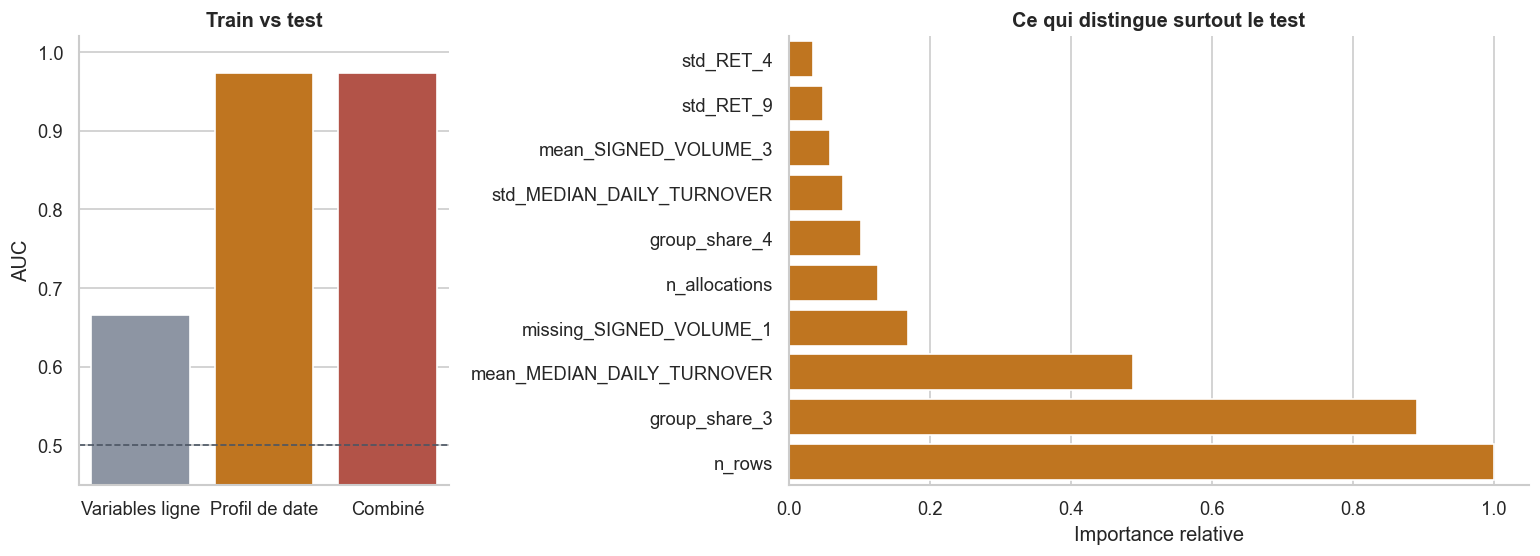

,bloc,AUC
0,Variables ligne,0.665788
1,Profil de date,0.972850
2,Combiné,0.973261


In [7]:
adv = json.load(open(OUT / "adversarial_stress_validation" / "summary.json"))
auc = pd.DataFrame({"bloc": list(adv["adversarial_auc"]), "AUC": list(adv["adversarial_auc"].values())})
auc["bloc"] = auc.bloc.map({"row":"Variables ligne", "date":"Profil de date", "combined":"Combiné"})
importance = pd.read_csv(OUT / "adversarial_stress_validation" / "adversarial_importance.csv")
importance = importance.query("block == 'combined'").nlargest(10, "gain_importance").copy()
importance["feature"] = importance.feature.str.replace("PROFILE_", "", regex=False).str.replace("date_", "", regex=False)
importance["importance_relative"] = importance.gain_importance / importance.gain_importance.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios":[.8, 1.6]})
sns.barplot(data=auc, x="bloc", y="AUC", hue="bloc", legend=False, palette=["#8A94A6", "#D97706", "#C44536"], ax=axes[0])
axes[0].axhline(.5, color="#4B5563", ls="--", lw=1)
axes[0].set(title="Train vs test", xlabel="", ylim=(.45, 1.02))
sns.barplot(data=importance.sort_values("importance_relative"), y="feature", x="importance_relative",
            color="#D97706", ax=axes[1])
axes[1].set(title="Ce qui distingue surtout le test", xlabel="Importance relative", ylabel="")
plt.tight_layout(); plt.show()
auc

## 6. À quoi servent les moyennes conditionnelles par quantile ?

**Question.** Le modèle V2 laisse-t-il un résidu systématique pour certaines
zones d'une feature, même si sa corrélation linéaire globale est faible ?

**Méthode.** On découpe une feature X en quantiles, puis on trace la moyenne du
résidu OOF `y − probabilité V2` dans chaque quantile. Les barres couvrent un
intervalle à 95 %. La feature est uniquement construite avec X : aucune cible
n'entre dans le modèle.

**Lecture.** Une courbe non plate suggère une relation non linéaire que la
logistique ne représente pas. Mais la courbe est exploratoire : après avoir
choisi une transformation en regardant ces résidus, il faut la confirmer dans
une nouvelle CV. Les gains observés sur deux folds ont disparu sur huit folds.

**Conclusion.** Ces graphes expliquent où V2 se trompe en moyenne ; ils ne
constituent pas à eux seuls une preuve de gain prédictif.

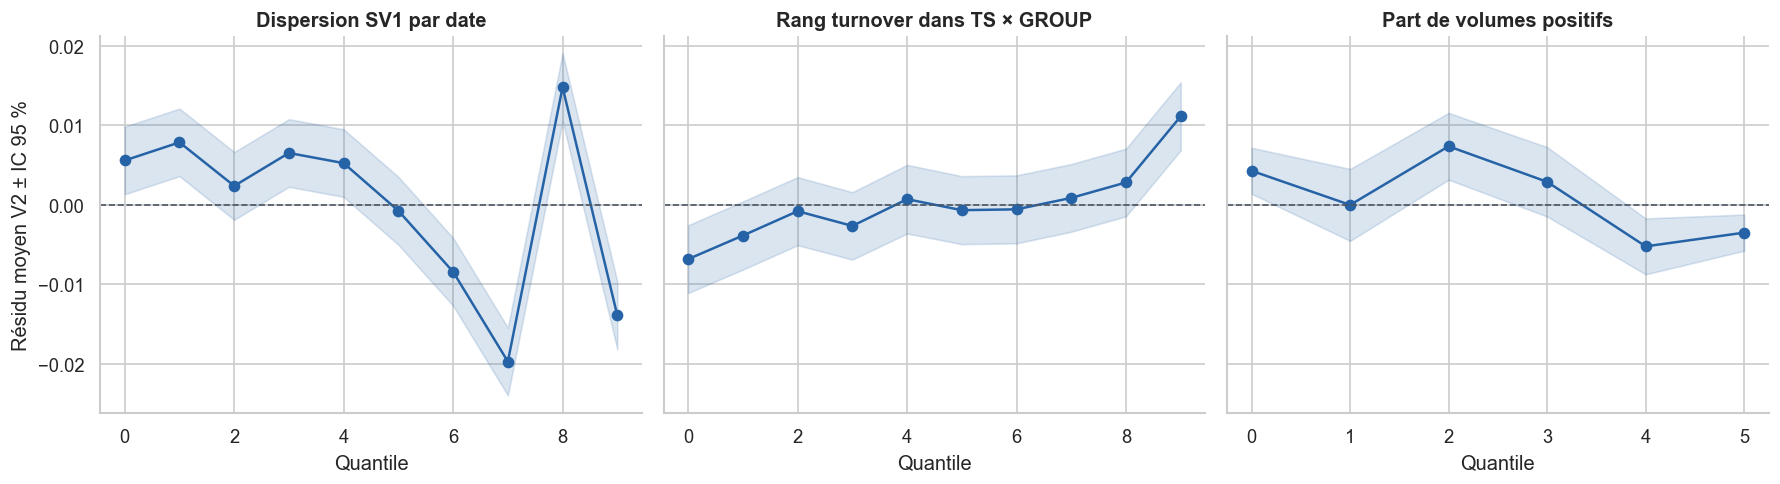

In [8]:
profiles = pd.read_csv(OUT / "conditional_quantile_audit" / "quantile_profiles.csv")
chosen = ["date_std_SIGNED_VOLUME_1", "group_date_rank_MEDIAN_DAILY_TURNOVER", "sv_positive_share_20"]
titles = ["Dispersion SV1 par date", "Rang turnover dans TS × GROUP", "Part de volumes positifs"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, feature, title in zip(axes, chosen, titles):
    d = profiles[profiles.feature.eq(feature)]
    ax.plot(d["quantile"], d.residual_mean, marker="o", color="#2563A6")
    ax.fill_between(d["quantile"], d.residual_mean - 1.96*d.residual_se,
                    d.residual_mean + 1.96*d.residual_se, color="#2563A6", alpha=.16)
    ax.axhline(0, color="#4B5563", lw=1, ls="--")
    ax.set(title=title, xlabel="Quantile")
axes[0].set_ylabel("Résidu moyen V2 ± IC 95 %")
plt.tight_layout(); plt.show()

## 7. Conclusions et nouveau protocole

### Ce qui est solide

- La CV est correctement séparée par dates entières.
- Le signal disponible est faible : AUC V2 ≈ 0,535.
- Les modèles testés font des erreurs largement corrélées.
- Le test diffère surtout par la structure de ses dates : 90 dates sur 120 ont
  278 lignes, alors que le train mélange plusieurs tailles.
- Sur les dates train complètes, V2 tombe autour de 51,9 %.
- Forcer 50 % de positifs, globalement ou par date, dégrade la validation.
- Les écarts de quelques centièmes de point entre modèles sont inférieurs à
  leurs intervalles d'incertitude appariés.

### Ce qu'on arrête

- optimiser de minuscules gains sur la seule CV globale ;
- multiplier les transformations de volumes sans gate ;
- supposer qu'un seuil équilibré corrigera automatiquement le public.

### Nouveau protocole proposé

1. conserver l'accuracy huit folds globale comme métrique secondaire ;
2. utiliser les dates complètes de 276 lignes comme métrique principale
   test-like ;
3. exiger un gain sur les deux métriques et une stabilité sur au moins 6 folds ;
4. n'utiliser le leaderboard que comme contrôle final, jamais comme cible
   d'optimisation.

## 8. Notebooks d'hypothèses

- [H1 — entraînement test-like](H1_test_like_training.ipynb)
- [H2 — AUC et seuils](H2_auc_and_thresholds.ipynb)
- [H3 — distributions des lignes unanimement fausses](H3_hard_vs_easy_dates.ipynb)
- [H4 — features non linéaires groupées](H4_nonlinear_group_features.ipynb)

Chaque notebook contient son protocole, ses incertitudes, ses graphiques et une
conclusion séparée afin de ne pas confondre exploration et résultat validé.